In [1]:
library(data.table)

In [5]:
library(parallel)

In [6]:
detectCores()

[1] 32

In [2]:
test = fread('/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz')

In [113]:
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [17]:
args = list()
args$variable = 'tdTom'

In [67]:
test2 = test %>%
    .[,variable := .[[args$variable]]]

In [28]:
sample_metadata = test[,celltype:=celltype.mapped_mnn]

In [31]:
to.plot <- sample_metadata[!is.na(celltype)] %>%
  .[,N:=.N,by=c("tdTom_corr","stage")] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("tdTom_corr","stage","celltype")] 

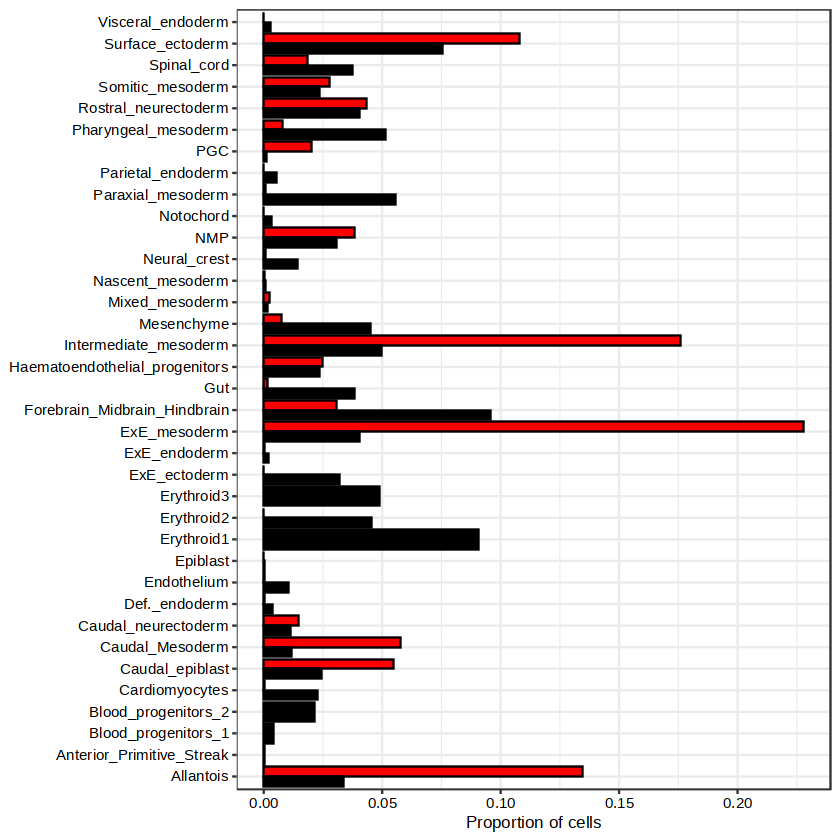

In [32]:
ggplot(to.plot, aes(x=celltype, y=celltype_proportion)) +
    geom_bar(aes(fill=tdTom_corr), stat="identity", color="black",  position = "dodge") +
    scale_fill_manual(values=c('black', 'red')) +
    coord_flip() +
    labs(y="Proportion of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 

In [33]:
head(to.plot)

tdTom_corr,stage,celltype,N,celltype_proportion
<lgl>,<chr>,<chr>,<int>,<dbl>
TRUE,E8.5,Rostral_neurectoderm,424,0.04340704
TRUE,E8.5,Intermediate_mesoderm,1718,0.17588043
TRUE,E8.5,Allantois,1315,0.13462326
TRUE,E8.5,Surface_ectoderm,1056,0.10810811
TRUE,E8.5,Caudal_Mesoderm,565,0.05784193
TRUE,E8.5,ExE_mesoderm,2227,0.22798935


In [ ]:
sd

In [40]:
to.plot <- sample_metadata[!is.na(celltype)] %>%
  .[,N:=.N,by=c("tdTom_corr","stage")] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("tdTom_corr","stage","celltype", 'sample')] %>%
  .[,mean_prop := mean(celltype_proportion),by=c("tdTom_corr","stage","celltype")] %>%
  .[,svd_prop := sd(celltype_proportion),by=c("tdTom_corr","stage","celltype")] %>% 
    unique(by=c("tdTom_corr","stage","celltype"))

In [41]:
head(to.plot)

tdTom_corr,stage,celltype,sample,N,celltype_proportion,mean_prop,svd_prop
<lgl>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
TRUE,E8.5,Rostral_neurectoderm,SLX-20795_SITTA11_HKTG2DRXY,46,0.004709255,0.01085176,0.01207766
TRUE,E8.5,Intermediate_mesoderm,SLX-20795_SITTA11_HKTG2DRXY,119,0.012182637,0.04397011,0.02964303
TRUE,E8.5,Allantois,SLX-20795_SITTA11_HKTG2DRXY,100,0.010237510,0.03365581,0.02531425
TRUE,E8.5,Surface_ectoderm,SLX-20795_SITTA11_HKTG2DRXY,161,0.016482391,0.02702703,0.01352411
TRUE,E8.5,Caudal_Mesoderm,SLX-20795_SITTA11_HKTG2DRXY,41,0.004197379,0.01446048,0.01097926
TRUE,E8.5,ExE_mesoderm,SLX-20795_SITTA11_HKTG2DRXY,97,0.009930385,0.05699734,0.04465342


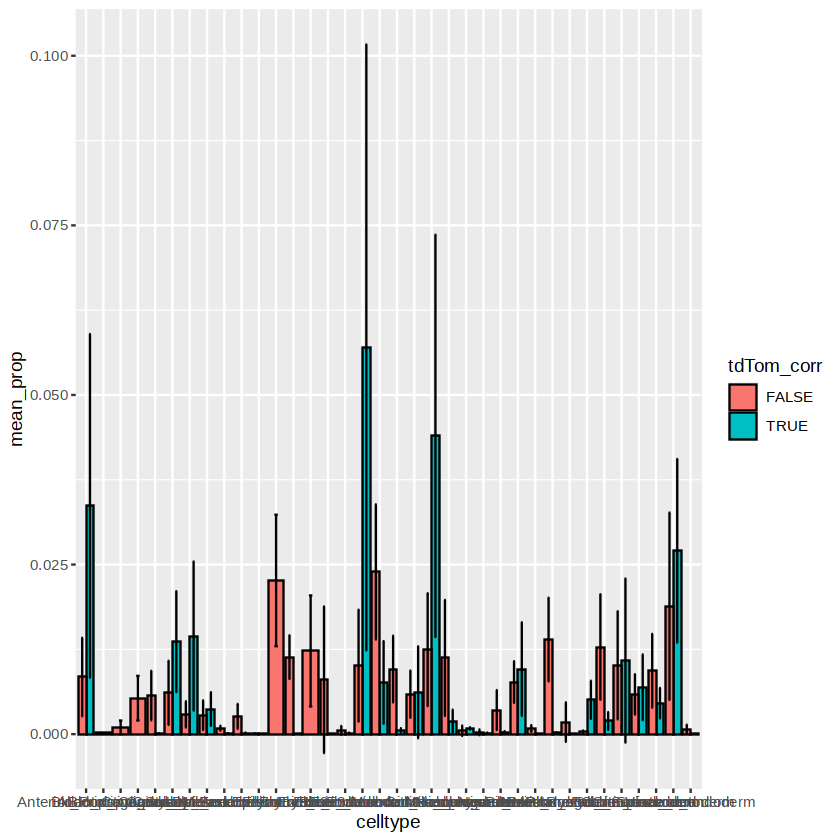

In [60]:
 ggplot(to.plot, aes(x=celltype, y=mean_prop, fill=tdTom_corr)) + 
  geom_bar(stat="identity", color="black", position=position_dodge()) +
  geom_errorbar(aes(ymin=mean_prop-svd_prop, ymax=mean_prop+svd_prop), width=.2,
                 position=position_dodge(.9)) 

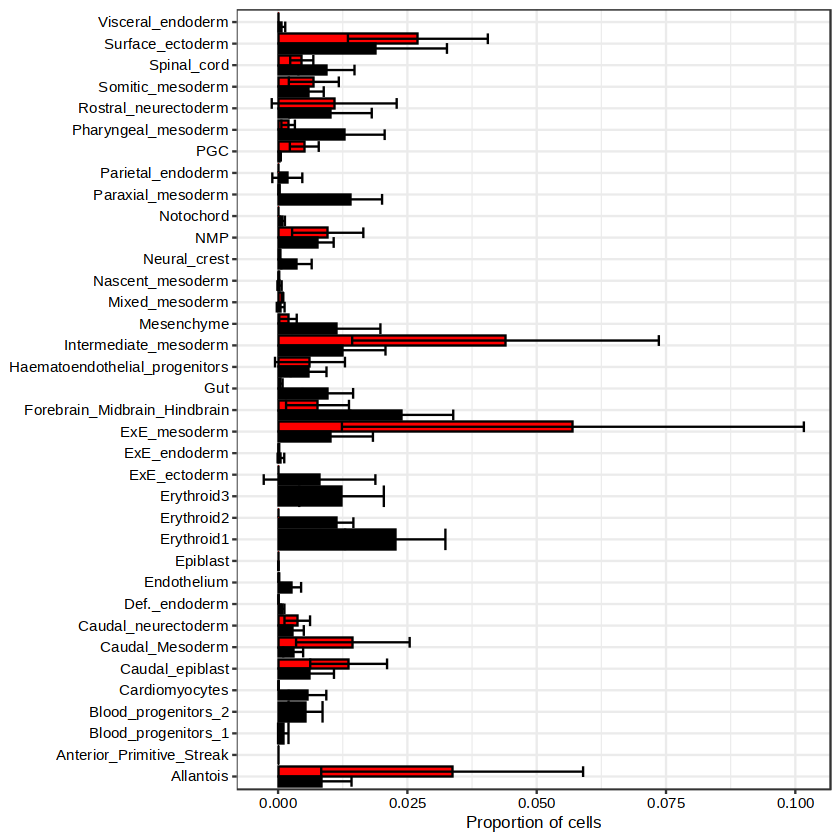

In [64]:
ggplot(to.plot, aes(x=celltype, y=mean_prop, fill=tdTom_corr)) + 
      geom_bar(stat="identity", color="black", position=position_dodge()) +
      geom_errorbar(aes(ymin=mean_prop-svd_prop, ymax=mean_prop+svd_prop), width=1,
                 position=position_dodge(.9)) +
    scale_fill_manual(values=c('black', 'red')) +
    coord_flip() +
    labs(y="Proportion of cells") +
    theme_bw() +
    theme(
      legend.position = "none",
      strip.background = element_blank(),
      strip.text = element_text(color="black", size=rel(0.5)),
      axis.title.x = element_text(color="black", size=rel(0.9)),
      axis.title.y = element_blank(),
      axis.text.y = element_text(size=rel(1), color="black"),
      axis.text.x = element_text(size=rel(1), color="black")
    ) 

In [109]:
to.plot <- sample_metadata[!is.na(celltype)][, pool:=str_replace_all(sample, opts$sample2pool)] %>%
  .[,N:=.N,by=c("tdTom_corr","stage")] %>%
  .[,.(N=.N, celltype_proportion=.N/unique(N)),by=c("tdTom_corr","stage","celltype", 'pool')] %>%
    dcast(pool + celltype ~ tdTom_corr, value.var='celltype_proportion') %>% 
    setnames(c('TRUE', 'FALSE'), c('KO', 'WT')) %>% 
    .[!is.na(WT)] %>% .[!is.na(KO)] %>% 
    .[,ratio:=KO/WT]

head(to.plot)

pool,celltype,WT,KO,ratio
<chr>,<chr>,<dbl>,<dbl>,<dbl>
pool1,Allantois,0.0031858407,0.0143325143,4.498816999
pool1,Caudal_Mesoderm,0.0010176991,0.0095208845,9.355303921
pool1,Caudal_epiblast,0.0027433628,0.0078828829,2.873437954
pool1,Caudal_neurectoderm,0.0009734513,0.0018427518,1.893008711
pool1,Def._endoderm,0.0005752212,0.0001023751,0.177975178
pool1,Erythroid2,0.0109734513,0.0001023751,0.009329344


In [119]:
summary(to.plot$ratio)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.00431  0.16500  0.83606  3.43316  2.66353 64.78296 

In [111]:
unique(to.plot$celltype)

[1] "Allantois"                      "Caudal_Mesoderm"               
 [3] "Caudal_epiblast"                "Caudal_neurectoderm"           
 [5] "Def._endoderm"                  "Erythroid2"                    
 [7] "ExE_endoderm"                   "ExE_mesoderm"                  
 [9] "Forebrain_Midbrain_Hindbrain"   "Gut"                           
[11] "Haematoendothelial_progenitors" "Intermediate_mesoderm"         
[13] "Mesenchyme"                     "Mixed_mesoderm"                
[15] "NMP"                            "Notochord"                     
[17] "PGC"                            "Paraxial_mesoderm"             
[19] "Pharyngeal_mesoderm"            "Rostral_neurectoderm"          
[21] "Somitic_mesoderm"               "Spinal_cord"                   
[23] "Surface_ectoderm"               "Visceral_endoderm"             
[25] "Cardiomyocytes"                 "Endothelium"                   
[27] "Epiblast"                       "Nascent_mesoderm"              
[29] "Neural_crest"                   "ExE_ectoderm"

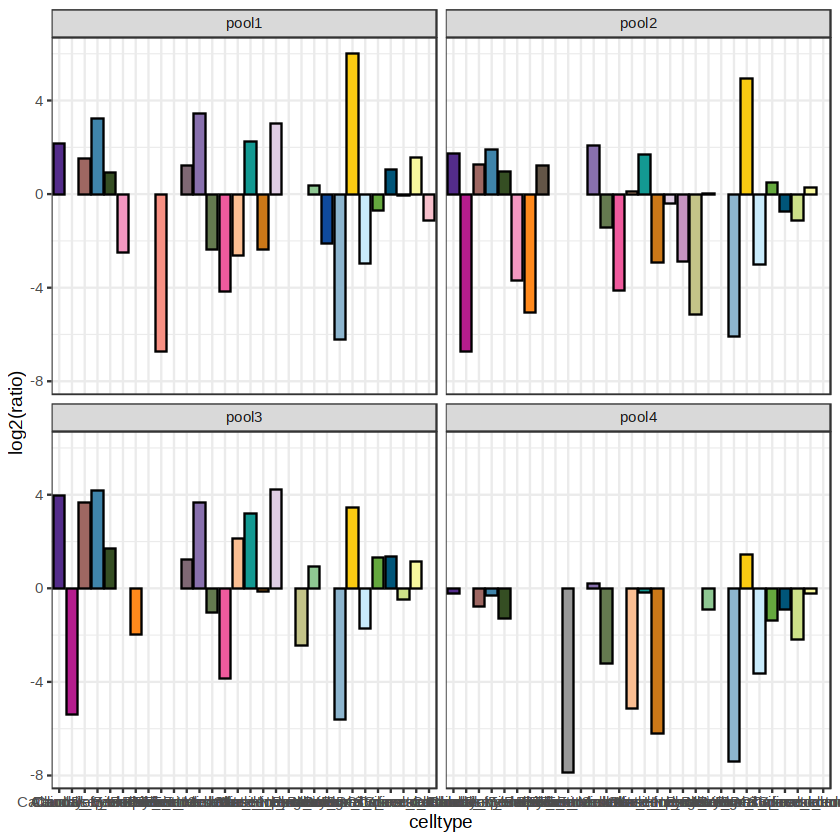

In [118]:
ggplot(to.plot, aes(celltype, log2(ratio+1e-100), fill=celltype)) + 
    geom_bar(stat='identity', color='black') + 
    scale_fill_manual(values=opts$celltype.colors) +
    facet_wrap(~pool) + 
    theme_bw() + 
    theme(legend.position='none')